In [ ]:
import nbformat as nbf

nb = nbf.v4.new_notebook()
cells = []

def md(src):
    cells.append(nbf.v4.new_markdown_cell(src.strip() + "\n"))

def code(src):
    cells.append(nbf.v4.new_code_cell(src.strip() + "\n"))

In [ ]:
# CELL 1 -- Install dependencies and detect hardware
!pip install -q pennylane pennylane-lightning scikit-learn pandas numpy matplotlib seaborn ucimlrepo torch scipy

# Optional: GPU-accelerated quantum simulator. Requires a CUDA-enabled
# environment with cuQuantum. Safe to fail -- we fall back gracefully.
!pip install -q pennylane-lightning-gpu 2>/dev/null || echo "lightning.gpu not installed (no CUDA/cuQuantum) -- will fall back to lightning.qubit"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 11.1 MB/s eta 0:00:00


In [ ]:
# CELL 2 -- Imports, seeds, device detection
import os, time, ast, io, zipfile, requests, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                              precision_score, recall_score)
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon

import pennylane as qml

np.random.seed(42)

# ---- Hardware detection ----
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", TORCH_DEVICE)
if TORCH_DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

N_QUBITS = 4
WINDOW_SIZE = 6

def get_qdevice(n_qubits):
    '''Pick the fastest available PennyLane simulator.'''
    for dev_name in ["lightning.gpu", "lightning.qubit", "default.qubit"]:
        try:
            dev = qml.device(dev_name, wires=n_qubits)
            print(f"Using PennyLane device: {dev_name}")
            return dev, dev_name
        except Exception:
            continue
    raise RuntimeError("No PennyLane simulator device available")

QDEV, QDEV_NAME = get_qdevice(N_QUBITS)

# Number of independent seeds used for mean/std and significance testing.
# 5 matched the original draft; raise to 10 for stronger statistics now
# that the pipeline runs faster (lightning.qubit / GPU neural nets).
SEEDS = [42, 7, 123, 999, 2024, 13, 77, 256, 512, 1024]

PyTorch device: cuda
GPU: Tesla T4
Using PennyLane device: lightning.gpu


In [ ]:
# CELL 3 -- Load Intel Berkeley Research Lab dataset (auto-download, no upload)
INTEL_URL = "http://db.csail.mit.edu/labdata/data.txt.gz"
intel_path = "data.txt.gz"

if not os.path.exists(intel_path):
    print("Downloading Intel Berkeley dataset...")
    r = requests.get(INTEL_URL, timeout=180)
    r.raise_for_status()
    with open(intel_path, "wb") as f:
        f.write(r.content)
    print("Downloaded", os.path.getsize(intel_path), "bytes")

cols = ['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light', 'voltage']
df_intel = pd.read_csv(intel_path, sep=' ', names=cols, na_values=['NaN'], compression='gzip')

# Sort by datetime first -- mandatory for temporal correctness
df_intel['datetime'] = pd.to_datetime(df_intel['date'] + ' ' + df_intel['time'], errors='coerce')
df_intel = df_intel.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

FEATURE_COLS_INTEL = ['temperature', 'humidity', 'light', 'voltage']
df_intel = df_intel[FEATURE_COLS_INTEL].dropna().reset_index(drop=True)

# Keep a tractable slice for Colab; raise this if your GPU run can afford it
INTEL_MAX_ROWS = 8000
df_intel = df_intel.iloc[:INTEL_MAX_ROWS].copy()

print("Intel dataset shape:", df_intel.shape)
print(df_intel.describe().round(3))

Downloaded 34422518 bytes
Intel dataset shape: (8000, 4)
       temperature  humidity     light   voltage
count     8000.000  8000.000  8000.000  8000.000
mean        18.082    40.578   140.317     2.668
std          0.883     1.988   142.168     0.082
min         15.030    33.490     0.460     2.464
25%         17.636    39.280    71.760     2.651
50%         18.195    39.959   108.560     2.675
75%         18.695    41.444   158.240     2.687
max         21.576    47.897   890.560     3.159


In [ ]:
# CELL 4 -- Load UCI Air Quality dataset
from ucimlrepo import fetch_ucirepo

print("Downloading Air Quality dataset...")
aq = fetch_ucirepo(id=360)
df_aq = aq.data.features.select_dtypes(include='number')

print(f"Rows before -200 removal: {len(df_aq)}")
df_aq = df_aq.replace(-200, np.nan)
df_aq = df_aq.dropna()
print(f"Rows after  -200 removal: {len(df_aq)}")

AQ_MAX_ROWS = 6000
df_aq = df_aq.iloc[:AQ_MAX_ROWS].copy()
df_aq = df_aq.dropna(axis=1).iloc[:, :4]
df_aq.columns = ['feature_1', 'feature_2', 'feature_3', 'feature_4']

assert df_aq.isnull().sum().sum() == 0
assert (df_aq.values == -200).sum() == 0
print("Air Quality final shape:", df_aq.shape)
print(df_aq.describe().round(3))

Rows before -200 removal: 9357
Rows after  -200 removal: 827
Air Quality final shape: (827, 4)
       feature_1  feature_2  feature_3  feature_4
count    827.000    827.000    827.000    827.000
mean       2.354   1207.879    231.025     10.771
std        1.409    241.817    208.462      7.418
min        0.300    753.000      7.000      0.500
25%        1.300   1017.000     77.000      4.800
50%        2.000   1172.000    157.000      9.100
75%        3.100   1380.000    318.500     14.800
max        8.100   2040.000   1189.000     39.200


In [ ]:
from google.colab import files
files.upload()  # select the downloaded kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sugandasutar","key":"09b96a9975b1e42d97079e589567e647"}'}

In [ ]:
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# CELL 5 -- Load NASA SMAP telemetry (telemanom dataset, real labeled anomalies)
# The original S3 bucket (s3-us-west-2.amazonaws.com/telemanom/data.zip) now
# returns 403 Forbidden -- it appears to have been taken down. This cell
# tries multiple sources and degrades gracefully: if NO source works, SMAP
# is simply skipped and the rest of the notebook runs on Intel + AQ only
# (DATASETS dict below only includes datasets that loaded successfully).

SMAP_AVAILABLE = False
SMAP_CHANNEL = "P-1"

def _has_telemanom_data():
    return (os.path.exists("data/labeled_anomalies.csv") or os.path.exists("labeled_anomalies.csv")) and \
           (os.path.exists("data/train") or os.path.exists("train"))

# --- Source 1: original S3 bucket (kept for completeness; currently 403) ---
if not _has_telemanom_data():
    SMAP_URL = "https://s3-us-west-2.amazonaws.com/telemanom/data.zip"
    try:
        print("Trying source 1/2: telemanom S3 bucket...")
        r = requests.get(SMAP_URL, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall(".")
        print("  Success.")
    except Exception as e:
        print(f"  Failed ({e}).")

# --- Source 2: Kaggle mirror (current official source per telemanom README) ---
# Requires a Kaggle API token. In Colab:
#   1. Go to kaggle.com -> Account -> Create New API Token (downloads kaggle.json)
#   2. Upload it: from google.colab import files; files.upload()  -> select kaggle.json
#   3. Run: !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# Do this BEFORE running this cell if Source 1 fails.
if not _has_telemanom_data():
    kaggle_token = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(kaggle_token):
        try:
            print("Trying source 2/2: Kaggle (patrickfleith/nasa-anomaly-detection-dataset-smap-msl)...")
            os.system("pip install -q kaggle")
            os.system("kaggle datasets download -d patrickfleith/nasa-anomaly-detection-dataset-smap-msl -p . --unzip")
            # This dataset unzips to a 'data/data/...' structure per telemanom instructions
            if os.path.exists("data/data") and not os.path.exists("data/train"):
                os.system("mv data/data/* data/ && rmdir data/data")
            print("  Success." if _has_telemanom_data() else "  Did not produce expected structure.")
        except Exception as e:
            print(f"  Failed ({e}).")
    else:
        print("Trying source 2/2: Kaggle... SKIPPED (no ~/.kaggle/kaggle.json found).")
        print("  To enable: upload your Kaggle API token as described in the comment above, then re-run this cell.")

if not _has_telemanom_data():
    print("\n" + "="*70)
    print("SMAP dataset NOT available -- continuing with Intel + Air Quality only.")
    print("To add SMAP later: get the data via Kaggle (see comments above) and")
    print("re-run this cell, then re-run cells 10, 11 onward.")
    print("="*70)
else:
    labels_df = pd.read_csv("labeled_anomalies.csv") if os.path.exists("labeled_anomalies.csv") \
                else pd.read_csv("data/labeled_anomalies.csv")

    smap_channels = labels_df[labels_df['spacecraft'] == 'SMAP'].copy()
    smap_channels['num_values'] = smap_channels['num_values'].astype(int)
    print("Available SMAP channels (top 10 by length):")
    print(smap_channels.sort_values('num_values', ascending=False)[['chan_id', 'num_values', 'class']].head(10))

    # Pick a channel: P-1 is a commonly-used, reasonably sized SMAP channel with
    # real labeled point/contextual anomalies. Change SMAP_CHANNEL above to explore others.
    chan_row = labels_df[labels_df['chan_id'] == SMAP_CHANNEL].iloc[0]

    def _find_npy(split, chan):
        for prefix in ["data/", ""]:
            p = f"{prefix}{split}/{chan}.npy"
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f"{split}/{chan}.npy not found")

    X_smap_train = np.load(_find_npy("train", SMAP_CHANNEL))
    X_smap_test  = np.load(_find_npy("test", SMAP_CHANNEL))

    anomaly_sequences = ast.literal_eval(chan_row['anomaly_sequences'])
    y_smap_train = np.zeros(len(X_smap_train), dtype=int)   # training split is anomaly-free by construction
    y_smap_test  = np.zeros(len(X_smap_test), dtype=int)
    for (start, end) in anomaly_sequences:
        y_smap_test[start:end + 1] = 1

    print(f"\nSMAP channel {SMAP_CHANNEL}")
    print(f"  train: {X_smap_train.shape}  (assumed normal)")
    print(f"  test : {X_smap_test.shape}, anomaly rate = {y_smap_test.mean()*100:.2f}%")
    print(f"  feature dim: {X_smap_train.shape[1]}")
    SMAP_AVAILABLE = True

Trying source 1/2: telemanom S3 bucket...
  Failed (403 Client Error: Forbidden for url: https://s3-us-west-2.amazonaws.com/telemanom/data.zip).
Trying source 2/2: Kaggle (patrickfleith/nasa-anomaly-detection-dataset-smap-msl)...
  Success.
Available SMAP channels (top 10 by length):
   chan_id  num_values                                 class
20     D-3        8640                               [point]
15     A-1        8640                               [point]
14    E-13        8640  [contextual, contextual, contextual]
43     G-6        8640                               [point]
49     A-7        8631                          [contextual]
37     F-2        8626                               [point]
34     T-2        8625                               [point]
33     T-1        8612                   [point, contextual]
19     D-2        8595                               [point]
30     F-1        8584                               [point]

SMAP channel P-1
  train: (2872, 25)  (assu

In [ ]:
# CELL 6 -- Windowing, synthetic injection, and real-label windowing

def create_temporal_windows(X, window_size=WINDOW_SIZE):
    '''Sliding window over time-sorted data. Returns (N - w + 1, w * d) array.'''
    n = len(X) - window_size + 1
    windows = [X[i:i + window_size].flatten() for i in range(n)]
    X_win = np.array(windows)
    print(f"Windowed: {X.shape} -> {X_win.shape}  (window_size={window_size})")
    return X_win


def window_labels_any(y, window_size=WINDOW_SIZE):
    '''For real-label datasets: a window is anomalous if ANY sample in it is.'''
    n = len(y) - window_size + 1
    return np.array([int(y[i:i + window_size].max()) for i in range(n)], dtype=int)


def inject_realistic_anomalies(X_win, contamination=0.01, seed=42):
    '''
    Three anomaly types simulating real environmental sensor faults:

    Type A (Point):       sudden spike across all features -- sensor malfunction
    Type B (Contextual):  temporal drift across 3 consecutive windows -- calibration failure
    Type C (Noise):       Gaussian corruption -- transmission error
    '''
    rng = np.random.RandomState(seed)
    X = X_win.copy().astype(float)
    n = len(X)
    n_anomalies = max(int(n * contamination), 9)
    n_each = max(n_anomalies // 3, 3)

    all_idx = rng.permutation(n)
    idx_A = all_idx[0:n_each]
    idx_B = all_idx[n_each:2 * n_each]
    idx_C = all_idx[2 * n_each:3 * n_each]

    labels = np.zeros(n, dtype=int)

    # Type A: Point anomaly -- spike 3-5x current value
    spike = rng.uniform(3.0, 5.0, size=(len(idx_A), X.shape[1]))
    X[idx_A] *= spike
    labels[idx_A] = 1

    # Type B: Contextual anomaly -- linear drift across 3 consecutive windows
    for idx in idx_B:
        if idx < 2:
            X[idx] += rng.uniform(2.0, 4.0, size=X.shape[1])
        else:
            drift_magnitude = rng.uniform(2.0, 4.0)
            drift = np.linspace(0, drift_magnitude, 3)
            X[idx - 2:idx + 1] += drift.reshape(-1, 1)
        labels[idx] = 1

    # Type C: Noise anomaly -- Gaussian corruption scaled to feature std
    noise_std = X.std(axis=0) * 2.0
    noise = rng.normal(0, noise_std, size=(len(idx_C), X.shape[1]))
    X[idx_C] += noise
    labels[idx_C] = 1

    total = labels.sum()
    ratio = int((labels == 0).sum() / total) if total > 0 else 0
    print(f"Anomalies injected -- Point: {len(idx_A)}, Contextual: {len(idx_B)}, Noise: {len(idx_C)}")
    print(f"Total: {total} anomalies / {n} samples  (approx 1:{ratio})")
    return X, labels


def scale_and_pca(X_win, n_qubits=N_QUBITS, seed=42):
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_win)
    pca = PCA(n_components=n_qubits, whiten=True, random_state=seed)
    X_pca = pca.fit_transform(X_std)
    print(f"PCA variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    return X_pca, pca, scaler
def subsample_keep_anomalies(X, y, max_samples, seed=42):
    """Subsample to at most max_samples rows, guaranteeing ALL anomaly rows
    are kept (filling the remainder with randomly-selected normal rows).
    This avoids the failure mode where naive [:max_samples] truncation
    happens to land entirely within a contiguous anomaly-free region
    (e.g. SMAP's anomaly-free training split)."""
    n = len(y)
    if n <= max_samples:
        return X, y
    rng = np.random.RandomState(seed)
    anom_idx = np.where(y == 1)[0]
    normal_idx = np.where(y == 0)[0]
    if len(anom_idx) >= max_samples:
        keep_idx = rng.choice(anom_idx, max_samples, replace=False)
    else:
        n_normal_keep = max_samples - len(anom_idx)
        normal_keep = rng.choice(normal_idx, min(n_normal_keep, len(normal_idx)), replace=False)
        keep_idx = np.concatenate([anom_idx, normal_keep])
    keep_idx = np.sort(keep_idx)
    return X[keep_idx], y[keep_idx]


In [ ]:
# CELL 7 -- QIAFP class

class QIAFP:
    '''Quantum Imbalance-Aware Feature Projection (QIAFP).'''

    def __init__(self, n_qubits=4, seed=42, device=None):
        self.n_qubits = n_qubits
        self.seed = seed
        rng = np.random.RandomState(seed)
        self.params = rng.uniform(-np.pi, np.pi, size=(n_qubits, 3))
        self.dev = device if device is not None else QDEV
        self.circuit = self._build_circuit()
        print(f"QIAFP initialized | qubits={n_qubits} | Hilbert dim=2^{n_qubits}={2**n_qubits} "
              f"| seed={seed} | device={QDEV_NAME}")

    def _build_circuit(self):
        params = self.params
        n_qubits = self.n_qubits

        @qml.qnode(self.dev)
        def circuit(x):
            for i in range(n_qubits):
                qml.RY(float(np.tanh(x[i] / 2.0) * np.pi), wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[n_qubits - 1, 0])
            for i in range(n_qubits):
                qml.RX(float(params[i, 0]), wires=i)
                qml.RY(float(params[i, 1]), wires=i)
                qml.RZ(float(params[i, 2]), wires=i)
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        return circuit

    def transform(self, X, verbose=True):
        results = []
        for i, sample in enumerate(X):
            if verbose and i % 200 == 0:
                print(f"  QIAFP transform: {i}/{len(X)}", end='\r')
            results.append(self.circuit(sample))
        if verbose:
            print(f"  QIAFP transform: {len(X)}/{len(X)} done          ")
        return np.array(results)

    def __repr__(self):
        return f"QIAFP(n_qubits={self.n_qubits}, seed={self.seed}, device={QDEV_NAME})"


qiafp = QIAFP(n_qubits=N_QUBITS, seed=42)

# Sanity check
_test = qiafp.transform(np.random.randn(3, N_QUBITS), verbose=False)
print("Sanity check output range (expect within [-1, 1]):", _test.min(), _test.max())


QIAFP initialized | qubits=4 | Hilbert dim=2^4=16 | seed=42 | device=lightning.gpu
Sanity check output range (expect within [-1, 1]): -0.44636457707409805 0.29497236888179873


In [ ]:
# CELL 8 -- Build features: Intel Berkeley
MAX_SAMPLES = 3000

print("=== INTEL BERKELEY ===")
scaler_intel = MinMaxScaler()
X_intel_scaled = scaler_intel.fit_transform(df_intel.values)

X_intel_win = create_temporal_windows(X_intel_scaled, WINDOW_SIZE)
X_intel_injected, y_intel = inject_realistic_anomalies(X_intel_win, contamination=0.01, seed=42)
X_intel_pca, pca_intel, _ = scale_and_pca(X_intel_injected, seed=42)

X_intel_cl, y_intel_sub = subsample_keep_anomalies(X_intel_pca, y_intel, MAX_SAMPLES, seed=42)

print("Transforming Intel with QIAFP...")
X_intel_qn = qiafp.transform(X_intel_cl)
X_intel_hy = np.hstack([X_intel_cl, X_intel_qn])
print(f"Intel -- classical {X_intel_cl.shape}, quantum {X_intel_qn.shape}, hybrid {X_intel_hy.shape}")
print(f"Anomaly rate: {y_intel_sub.mean()*100:.2f}%  ({y_intel_sub.sum()} / {len(y_intel_sub)})")


=== INTEL BERKELEY ===
Windowed: (8000, 4) -> (7995, 24)  (window_size=6)
Anomalies injected -- Point: 26, Contextual: 26, Noise: 26
Total: 78 anomalies / 7995 samples  (approx 1:101)
PCA variance retained: 75.0%
Transforming Intel with QIAFP...
  QIAFP transform: 3000/3000 done          
Intel -- classical (3000, 4), quantum (3000, 4), hybrid (3000, 8)
Anomaly rate: 2.60%  (78 / 3000)


In [ ]:
# CELL 9 -- Build features: Air Quality
print("=== AIR QUALITY UCI ===")
scaler_aq = MinMaxScaler()
X_aq_scaled = scaler_aq.fit_transform(df_aq.values)

X_aq_win = create_temporal_windows(X_aq_scaled, WINDOW_SIZE)
X_aq_injected, y_aq = inject_realistic_anomalies(X_aq_win, contamination=0.03, seed=42)
X_aq_pca, pca_aq, _ = scale_and_pca(X_aq_injected, seed=42)

X_aq_cl, y_aq_sub = subsample_keep_anomalies(X_aq_pca, y_aq, MAX_SAMPLES, seed=42)

print("Transforming Air Quality with QIAFP...")
X_aq_qn = qiafp.transform(X_aq_cl)
X_aq_hy = np.hstack([X_aq_cl, X_aq_qn])
print(f"AQ -- classical {X_aq_cl.shape}, quantum {X_aq_qn.shape}, hybrid {X_aq_hy.shape}")
print(f"Anomaly rate: {y_aq_sub.mean()*100:.2f}%  ({y_aq_sub.sum()} / {len(y_aq_sub)})")


=== AIR QUALITY UCI ===
Windowed: (827, 4) -> (822, 24)  (window_size=6)
Anomalies injected -- Point: 8, Contextual: 8, Noise: 8
Total: 24 anomalies / 822 samples  (approx 1:33)
PCA variance retained: 94.6%
Transforming Air Quality with QIAFP...
  QIAFP transform: 822/822 done          
AQ -- classical (822, 4), quantum (822, 4), hybrid (822, 8)
Anomaly rate: 2.92%  (24 / 822)


In [ ]:
# CELL 10 -- Build features: NASA SMAP (real labels, no synthetic injection)
# Only runs if Cell 5 successfully loaded SMAP data (SMAP_AVAILABLE == True).

if SMAP_AVAILABLE:
    print("=== NASA SMAP (real labels) ===")

    # Fit MinMax scaler on the (anomaly-free) training split only, apply to both
    scaler_smap = MinMaxScaler()
    scaler_smap.fit(X_smap_train)
    X_smap_train_scaled = scaler_smap.transform(X_smap_train)
    X_smap_test_scaled = scaler_smap.transform(X_smap_test)

    X_smap_all_scaled = np.vstack([X_smap_train_scaled, X_smap_test_scaled])
    y_smap_all = np.concatenate([y_smap_train, y_smap_test])

    X_smap_win = create_temporal_windows(X_smap_all_scaled, WINDOW_SIZE)
    y_smap_win = window_labels_any(y_smap_all, WINDOW_SIZE)

    X_smap_pca, pca_smap, _ = scale_and_pca(X_smap_win, seed=42)

    X_smap_cl, y_smap_sub = subsample_keep_anomalies(X_smap_pca, y_smap_win, MAX_SAMPLES, seed=42)

    print("Transforming SMAP with QIAFP...")
    X_smap_qn = qiafp.transform(X_smap_cl)
    X_smap_hy = np.hstack([X_smap_cl, X_smap_qn])
    print(f"SMAP -- classical {X_smap_cl.shape}, quantum {X_smap_qn.shape}, hybrid {X_smap_hy.shape}")
    print(f"Anomaly rate: {y_smap_sub.mean()*100:.2f}%  ({y_smap_sub.sum()} / {len(y_smap_sub)})")

    if y_smap_sub.sum() < 10:
        print("\nWARNING: very few anomaly windows for this channel. Consider a different "
              "SMAP_CHANNEL in Cell 5 (e.g. one with a higher 'num_values' and a labeled "
              "'point'/'contextual' class), or reduce WINDOW_SIZE.")
else:
    print("SMAP_AVAILABLE is False -- skipping SMAP feature construction. "
          "The notebook will continue with Intel + Air Quality only.")


=== NASA SMAP (real labels) ===
Windowed: (11377, 25) -> (11372, 150)  (window_size=6)
PCA variance retained: 25.8%
Transforming SMAP with QIAFP...
  QIAFP transform: 3000/3000 done          
SMAP -- classical (3000, 4), quantum (3000, 4), hybrid (3000, 8)
Anomaly rate: 25.53%  (766 / 3000)


In [ ]:
# CELL 11 -- Splits + normal-only training sets

def make_splits_triple(X_cl, X_qn, X_hy, y, test_size=0.3, seed=42):
    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(idx, test_size=test_size, stratify=y, random_state=seed)
    return {
        'X_cl_train': X_cl[idx_train], 'X_cl_test': X_cl[idx_test],
        'X_qn_train': X_qn[idx_train], 'X_qn_test': X_qn[idx_test],
        'X_hy_train': X_hy[idx_train], 'X_hy_test': X_hy[idx_test],
        'y_train': y[idx_train], 'y_test': y[idx_test],
    }

def extract_normals(splits):
    return {
        'cl': splits['X_cl_train'][splits['y_train'] == 0],
        'qn': splits['X_qn_train'][splits['y_train'] == 0],
        'hy': splits['X_hy_train'][splits['y_train'] == 0],
    }

DATASETS = {}

splits_intel = make_splits_triple(X_intel_cl, X_intel_qn, X_intel_hy, y_intel_sub)
DATASETS['Intel Berkeley'] = {
    'splits': splits_intel, 'normals': extract_normals(splits_intel),
    'contamination': float(y_intel_sub.mean()),
}

splits_aq = make_splits_triple(X_aq_cl, X_aq_qn, X_aq_hy, y_aq_sub)
DATASETS['Air Quality UCI'] = {
    'splits': splits_aq, 'normals': extract_normals(splits_aq),
    'contamination': float(y_aq_sub.mean()),
}

if SMAP_AVAILABLE:
    splits_smap = make_splits_triple(X_smap_cl, X_smap_qn, X_smap_hy, y_smap_sub)
    DATASETS['NASA SMAP'] = {
        'splits': splits_smap, 'normals': extract_normals(splits_smap),
        'contamination': float(y_smap_sub.mean()),
    }
else:
    print("NASA SMAP not available -- DATASETS contains Intel Berkeley + Air Quality only.")

for name, d in DATASETS.items():
    s = d['splits']
    print(f"{name:18s} train={len(s['y_train']):5d} (anom={s['y_train'].sum():3d})  "
          f"test={len(s['y_test']):5d} (anom={s['y_test'].sum():3d})  "
          f"contamination(used for models)={d['contamination']:.4f}")


Intel Berkeley     train= 2100 (anom= 55)  test=  900 (anom= 23)  contamination(used for models)=0.0260
Air Quality UCI    train=  575 (anom= 17)  test=  247 (anom=  7)  contamination(used for models)=0.0292
NASA SMAP          train= 2100 (anom=536)  test=  900 (anom=230)  contamination(used for models)=0.2553


In [ ]:
# CELL 12 -- PyTorch Autoencoder and Deep SVDD detectors

class TorchAutoencoderDetector:
    def __init__(self, input_dim, hidden_dim=8, latent_dim=2, contamination=0.05,
                 epochs=100, lr=1e-3, random_state=42, device=None):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.contamination = contamination
        self.epochs = epochs
        self.lr = lr
        self.random_state = random_state
        self.device = device if device is not None else TORCH_DEVICE

    def get_params(self, deep=True):
        return {'input_dim': self.input_dim, 'hidden_dim': self.hidden_dim,
                'latent_dim': self.latent_dim, 'contamination': self.contamination,
                'epochs': self.epochs, 'lr': self.lr, 'random_state': self.random_state}

    def _build(self):
        torch.manual_seed(self.random_state)
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim), nn.ReLU(),
            nn.Linear(self.hidden_dim, self.latent_dim), nn.ReLU(),
            nn.Linear(self.latent_dim, self.hidden_dim), nn.ReLU(),
            nn.Linear(self.hidden_dim, self.input_dim),
        ).to(self.device)

    def fit(self, X):
        self._build()
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        opt = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()
        self.model.train()
        for _ in range(self.epochs):
            opt.zero_grad()
            recon = self.model(X_t)
            loss = loss_fn(recon, X_t)
            loss.backward()
            opt.step()
        self.model.eval()
        with torch.no_grad():
            errors = ((self.model(X_t) - X_t) ** 2).mean(dim=1).cpu().numpy()
        self.threshold_ = np.quantile(errors, 1 - self.contamination)
        return self

    def _errors(self, X):
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        self.model.eval()
        with torch.no_grad():
            return ((self.model(X_t) - X_t) ** 2).mean(dim=1).cpu().numpy()

    def predict(self, X):
        return np.where(self._errors(X) > self.threshold_, -1, 1)

    def score_samples(self, X):
        return -self._errors(X)


class DeepSVDDDetector:
    def __init__(self, input_dim, hidden_dim=8, latent_dim=2, contamination=0.05,
                 epochs=100, lr=1e-3, random_state=42, device=None):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.contamination = contamination
        self.epochs = epochs
        self.lr = lr
        self.random_state = random_state
        self.device = device if device is not None else TORCH_DEVICE

    def get_params(self, deep=True):
        return {'input_dim': self.input_dim, 'hidden_dim': self.hidden_dim,
                'latent_dim': self.latent_dim, 'contamination': self.contamination,
                'epochs': self.epochs, 'lr': self.lr, 'random_state': self.random_state}

    def _build(self):
        torch.manual_seed(self.random_state)
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim), nn.ReLU(),
            nn.Linear(self.hidden_dim, self.latent_dim),
        ).to(self.device)

    def fit(self, X):
        self._build()
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        opt = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        with torch.no_grad():
            self.center = self.net(X_t).mean(dim=0)
        self.net.train()
        for _ in range(self.epochs):
            opt.zero_grad()
            z = self.net(X_t)
            loss = ((z - self.center) ** 2).sum(dim=1).mean()
            loss.backward()
            opt.step()
        self.net.eval()
        with torch.no_grad():
            dist = ((self.net(X_t) - self.center) ** 2).sum(dim=1).cpu().numpy()
        self.threshold_ = np.quantile(dist, 1 - self.contamination)
        return self

    def _dist(self, X):
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)
        self.net.eval()
        with torch.no_grad():
            return ((self.net(X_t) - self.center) ** 2).sum(dim=1).cpu().numpy()

    def predict(self, X):
        return np.where(self._dist(X) > self.threshold_, -1, 1)

    def score_samples(self, X):
        return -self._dist(X)

print("Neural detector classes defined.")


Neural detector classes defined.


In [ ]:
# CELL 13 -- Evaluation harness

def evaluate_model(model, X_train, X_test, y_test):
    model.fit(X_train)
    raw_pred = model.predict(X_test)
    y_pred = np.where(raw_pred == -1, 1, 0)

    if hasattr(model, 'score_samples'):
        scores = -model.score_samples(X_test)
    elif hasattr(model, 'decision_function'):
        scores = -model.decision_function(X_test)
    else:
        scores = y_pred.astype(float)

    return {
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, scores) if len(set(y_test)) > 1 else float('nan'),
        'AUC-PR': average_precision_score(y_test, scores) if len(set(y_test)) > 1 else float('nan'),
    }


def safe_build_model(model_class, kwargs, seed):
    '''Only pass random_state if the model supports it (OC-SVM / LOF don't).'''
    try:
        probe = model_class(**kwargs)
        if hasattr(probe, 'get_params') and 'random_state' in probe.get_params():
            kwargs = {**kwargs, 'random_state': seed}
    except Exception:
        pass
    return model_class(**kwargs)


def evaluate_with_stats(model_class, model_kwargs, X_train_normal, X_test, y_test,
                         seeds=SEEDS, model_name="Model"):
    all_metrics = {k: [] for k in ['Precision', 'Recall', 'F1', 'AUC-ROC', 'AUC-PR']}
    for seed in seeds:
        np.random.seed(seed)
        model = safe_build_model(model_class, model_kwargs.copy(), seed)
        m = evaluate_model(model, X_train_normal, X_test, y_test)
        for k in all_metrics:
            all_metrics[k].append(m[k])

    summary = {}
    for k, vals in all_metrics.items():
        arr = np.array(vals, dtype=float)
        summary[k] = {'mean': float(np.nanmean(arr)), 'std': float(np.nanstd(arr)), 'raw': vals}

    print(f"  {model_name:32s} "
          + "  ".join(f"{k}={summary[k]['mean']:.3f}+/-{summary[k]['std']:.3f}" for k in summary))
    return summary

print("Evaluation harness ready.")


Evaluation harness ready.


In [ ]:
# CELL 14 -- Full experiment runner

def get_detector_configs(input_dim, contamination):
    return [
        (IsolationForest, {'contamination': contamination, 'n_estimators': 100}, "IF"),
        (OneClassSVM, {'nu': min(max(contamination, 1e-3), 0.5), 'kernel': 'rbf'}, "OC-SVM"),
        (LocalOutlierFactor, {'contamination': contamination, 'novelty': True}, "LOF"),
        (TorchAutoencoderDetector, {'input_dim': input_dim, 'contamination': contamination, 'epochs': 100}, "AE"),
        (DeepSVDDDetector, {'input_dim': input_dim, 'contamination': contamination, 'epochs': 100}, "DeepSVDD"),
    ]


def run_full_experiment(splits, normals, dataset_name, contamination):
    print(f"\n{'='*70}\n  DATASET: {dataset_name}  (contamination={contamination:.4f})\n{'='*70}")
    y_test = splits['y_test']
    results = {}
    configs = [
        ("Classical", normals['cl'], splits['X_cl_test']),
        ("Quantum-only", normals['qn'], splits['X_qn_test']),
        ("Hybrid (QIAFP)", normals['hy'], splits['X_hy_test']),
    ]
    for feat_label, X_tr_normal, X_te in configs:
        dim = X_tr_normal.shape[1]
        print(f"\n-- Feature condition: {feat_label} (dim={dim}) --")
        for model_class, kwargs, model_label in get_detector_configs(dim, contamination):
            name = f"{model_label} — {feat_label}"
            results[name] = evaluate_with_stats(model_class, kwargs, X_tr_normal, X_te, y_test, model_name=name)
    return results


ALL_RESULTS = {}
for name, d in DATASETS.items():
    ALL_RESULTS[name] = run_full_experiment(d['splits'], d['normals'], name, d['contamination'])

print("\nAll experiments complete.")



  DATASET: Intel Berkeley  (contamination=0.0260)

-- Feature condition: Classical (dim=4) --
  IF — Classical                   Precision=0.554+/-0.032  Recall=0.961+/-0.023  F1=0.702+/-0.030  AUC-ROC=0.997+/-0.001  AUC-PR=0.910+/-0.011
  OC-SVM — Classical               Precision=0.478+/-0.000  Recall=0.957+/-0.000  F1=0.638+/-0.000  AUC-ROC=0.972+/-0.000  AUC-PR=0.946+/-0.000
  LOF — Classical                  Precision=0.524+/-0.000  Recall=0.957+/-0.000  F1=0.677+/-0.000  AUC-ROC=0.996+/-0.000  AUC-PR=0.907+/-0.000
  AE — Classical                   Precision=0.577+/-0.024  Recall=0.970+/-0.034  F1=0.723+/-0.025  AUC-ROC=0.997+/-0.003  AUC-PR=0.941+/-0.012
  DeepSVDD — Classical             Precision=0.470+/-0.081  Recall=0.778+/-0.171  F1=0.584+/-0.109  AUC-ROC=0.954+/-0.038  AUC-PR=0.745+/-0.173

-- Feature condition: Quantum-only (dim=4) --
  IF — Quantum-only                Precision=0.223+/-0.037  Recall=0.248+/-0.048  F1=0.234+/-0.040  AUC-ROC=0.724+/-0.011  AUC-PR=0.163+/-

In [ ]:
# CELL 15 -- Significance testing

def run_significance_tests(all_results):
    rows = []
    detector_labels = ["IF", "OC-SVM", "LOF", "AE", "DeepSVDD"]
    metrics = ['Precision', 'Recall', 'F1', 'AUC-ROC', 'AUC-PR']
    for dataset_name, results in all_results.items():
        for det in detector_labels:
            cl_key = f"{det} — Classical"
            hy_key = f"{det} — Hybrid (QIAFP)"
            if cl_key not in results or hy_key not in results:
                continue
            for metric in metrics:
                cl_vals = np.array(results[cl_key][metric]['raw'], dtype=float)
                hy_vals = np.array(results[hy_key][metric]['raw'], dtype=float)
                diff = hy_vals - cl_vals
                if np.allclose(diff, 0):
                    p = 1.0
                    note = "identical across seeds"
                elif np.allclose(diff, diff[0]):
                    p = float('nan')
                    note = "constant non-zero diff (degenerate for Wilcoxon)"
                else:
                    try:
                        _, p = wilcoxon(hy_vals, cl_vals)
                        note = ""
                    except ValueError as e:
                        p = float('nan')
                        note = str(e)
                rows.append({
                    'Dataset': dataset_name, 'Detector': det, 'Metric': metric,
                    'Classical_mean': cl_vals.mean(), 'Hybrid_mean': hy_vals.mean(),
                    'Mean_diff': diff.mean(), 'p_value': p,
                    'significant_p<0.05': (p < 0.05) if not np.isnan(p) else False,
                    'note': note,
                })
    return pd.DataFrame(rows)


sig_df = run_significance_tests(ALL_RESULTS)
pd.set_option('display.width', 160)
print(sig_df.to_string(index=False))


        Dataset Detector    Metric  Classical_mean  Hybrid_mean  Mean_diff  p_value  significant_p<0.05                                             note
 Intel Berkeley       IF Precision        0.554009     0.490635  -0.063373 0.003906                True                                                 
 Intel Berkeley       IF    Recall        0.960870     0.817391  -0.143478 0.001953                True                                                 
 Intel Berkeley       IF        F1        0.702389     0.612399  -0.089990 0.001953                True                                                 
 Intel Berkeley       IF   AUC-ROC        0.996941     0.987690  -0.009251 0.001953                True                                                 
 Intel Berkeley       IF    AUC-PR        0.910371     0.762756  -0.147615 0.001953                True                                                 
 Intel Berkeley   OC-SVM Precision        0.478261     0.468085  -0.010176      Na

In [ ]:
# CELL 16 -- Fisher separability

def fisher_separability(X, y, label=""):
    X_normal, X_anomaly = X[y == 0], X[y == 1]
    if len(X_anomaly) == 0:
        print(f"[{label}] No anomalies -- skipping")
        return float('nan')
    mu_0, mu_1 = X_normal.mean(axis=0), X_anomaly.mean(axis=0)
    between = np.linalg.norm(mu_0 - mu_1) ** 2
    within = X_normal.var(axis=0).sum() + X_anomaly.var(axis=0).sum()
    S = between / (within + 1e-8)
    print(f"  [{label}] S = {S:.4f}  (between={between:.4f}, within={within:.4f})")
    return S


fisher_rows = []
for name, d in DATASETS.items():
    s = d['splits']
    y_test = s['y_test']
    print(f"\n=== {name} ===")
    for feat, key in [("Classical", "X_cl_test"), ("Quantum-only", "X_qn_test"), ("Hybrid (QIAFP)", "X_hy_test")]:
        S = fisher_separability(s[key], y_test, label=f"{name} / {feat}")
        fisher_rows.append({'Dataset': name, 'Feature': feat, 'Fisher_S': S})

fisher_df = pd.DataFrame(fisher_rows)
print("\n", fisher_df.to_string(index=False))



=== Intel Berkeley ===
  [Intel Berkeley / Classical] S = 0.7177  (between=62.5212, within=87.1180)
  [Intel Berkeley / Quantum-only] S = 0.1898  (between=0.1763, within=0.9290)
  [Intel Berkeley / Hybrid (QIAFP)] S = 0.7121  (between=62.6975, within=88.0470)

=== Air Quality UCI ===
  [Air Quality UCI / Classical] S = 0.7486  (between=27.5617, within=36.8194)
  [Air Quality UCI / Quantum-only] S = 0.1251  (between=0.1050, within=0.8389)
  [Air Quality UCI / Hybrid (QIAFP)] S = 0.7347  (between=27.6667, within=37.6584)

=== NASA SMAP ===
  [NASA SMAP / Classical] S = 0.0017  (between=0.0149, within=8.6374)
  [NASA SMAP / Quantum-only] S = 0.0034  (between=0.0019, within=0.5567)
  [NASA SMAP / Hybrid (QIAFP)] S = 0.0018  (between=0.0168, within=9.1940)

         Dataset        Feature  Fisher_S
 Intel Berkeley      Classical  0.717661
 Intel Berkeley   Quantum-only  0.189788
 Intel Berkeley Hybrid (QIAFP)  0.712091
Air Quality UCI      Classical  0.748565
Air Quality UCI   Quantum-only

Saved: tsne_intel_berkeley.pdf


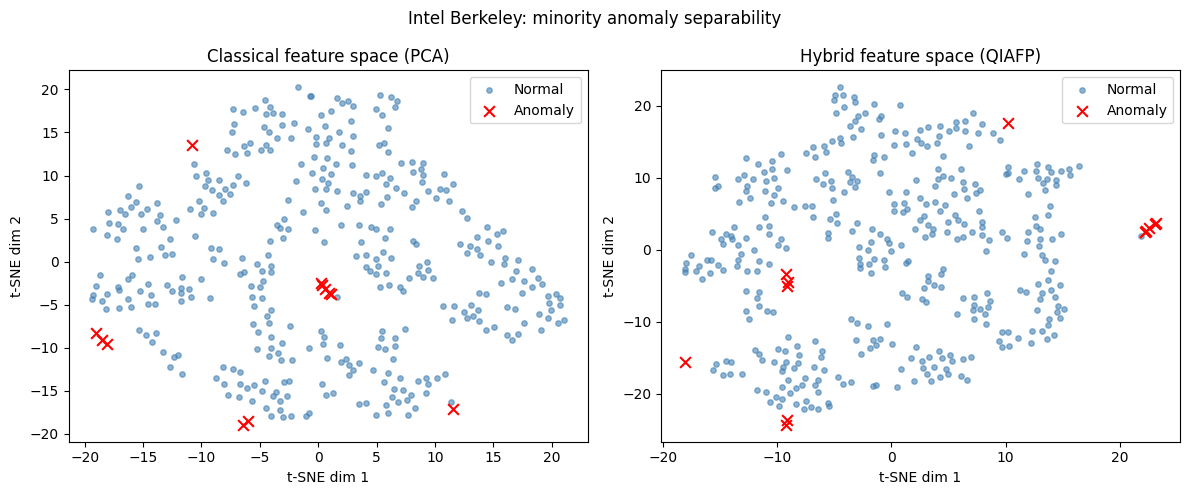

Saved: tsne_air_quality_uci.pdf


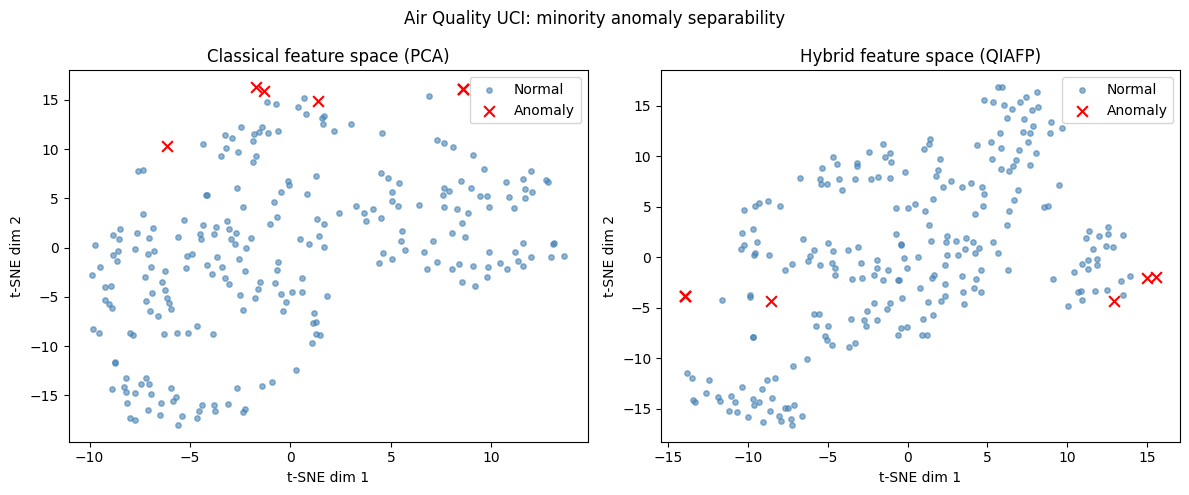

Saved: tsne_nasa_smap.pdf


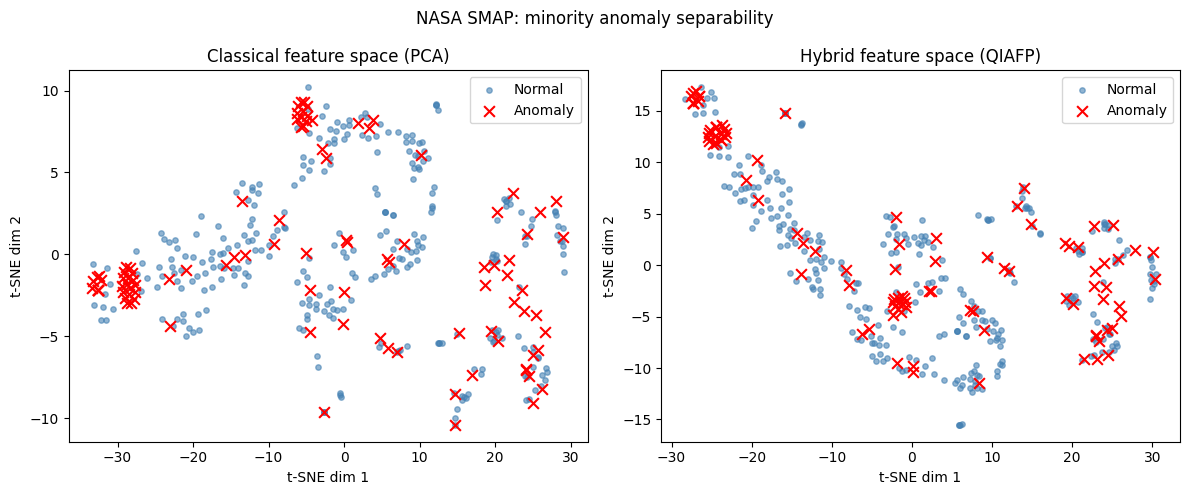

In [ ]:
# CELL 17 -- t-SNE plots

def plot_tsne_comparison(X_cl, X_hy, y, title_prefix, n_samples=400, save_path=None, seed=42):
    n = min(n_samples, len(y))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(y), n, replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, X, subtitle in zip(axes, [X_cl[idx], X_hy[idx]],
                                ["Classical feature space (PCA)", "Hybrid feature space (QIAFP)"]):
        tsne = TSNE(n_components=2, random_state=seed, perplexity=min(30, max(5, n // 5)), max_iter=1000)
        X_2d = tsne.fit_transform(X)
        ax.scatter(X_2d[y[idx] == 0, 0], X_2d[y[idx] == 0, 1], c='steelblue', label='Normal', alpha=0.6, s=15)
        ax.scatter(X_2d[y[idx] == 1, 0], X_2d[y[idx] == 1, 1], c='red', marker='x', label='Anomaly', s=60)
        ax.set_title(subtitle)
        ax.set_xlabel("t-SNE dim 1")
        ax.set_ylabel("t-SNE dim 2")
        ax.legend()
    fig.suptitle(f"{title_prefix}: minority anomaly separability")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print("Saved:", save_path)
    plt.show()


for name, d in DATASETS.items():
    s = d['splits']
    safe_name = name.lower().replace(' ', '_')
    plot_tsne_comparison(s['X_cl_test'], s['X_hy_test'], s['y_test'],
                          title_prefix=name, save_path=f"tsne_{safe_name}.pdf")


In [ ]:
# CELL 18 -- Imbalance ratio experiments

def run_imbalance_experiment(splits, dataset_name, ratios=(10, 50, 100)):
    y_full = splits['y_test']
    rows = []

    feature_keys = {'Classical': 'X_cl_test', 'Hybrid (QIAFP)': 'X_hy_test'}

    for feat_label, key in feature_keys.items():
        X_full = splits[key]
        X_normal = X_full[y_full == 0]
        X_anomaly = X_full[y_full == 1]
        if len(X_anomaly) == 0:
            print(f"[{dataset_name}/{feat_label}] No anomalies in test set -- skipping")
            continue

        for ratio in ratios:
            n_anom = len(X_anomaly)
            n_normal = min(n_anom * ratio, len(X_normal))
            contamination = round(n_anom / (n_anom + n_normal), 4)

            X_imb = np.vstack([X_normal[:n_normal], X_anomaly])
            y_imb = np.hstack([np.zeros(n_normal), np.ones(n_anom)]).astype(int)
            X_imb_normal = X_imb[y_imb == 0]

            dim = X_imb.shape[1]
            for model_class, kwargs, model_label in get_detector_configs(dim, contamination):
                summary = evaluate_with_stats(model_class, kwargs, X_imb_normal, X_imb, y_imb,
                                               seeds=SEEDS, model_name=f"{dataset_name}/{feat_label}/1:{ratio}/{model_label}")
                row = {'Dataset': dataset_name, 'Feature': feat_label, 'Ratio': f"1:{ratio}",
                       'Detector': model_label, 'n_normal': n_normal, 'n_anomaly': n_anom}
                for m in ['Precision', 'Recall', 'F1', 'AUC-ROC', 'AUC-PR']:
                    row[f'{m}_mean'] = summary[m]['mean']
                    row[f'{m}_std'] = summary[m]['std']
                rows.append(row)

    return pd.DataFrame(rows)


imbalance_dfs = []
for name, d in DATASETS.items():
    df_imb = run_imbalance_experiment(d['splits'], name)
    imbalance_dfs.append(df_imb)

imbalance_df = pd.concat(imbalance_dfs, ignore_index=True)
print("\nImbalance ratio experiment results (head):")
print(imbalance_df.head(20).to_string(index=False))


  Intel Berkeley/Classical/1:10/IF Precision=0.523+/-0.000  Recall=1.000+/-0.000  F1=0.687+/-0.000  AUC-ROC=0.995+/-0.000  AUC-PR=0.917+/-0.022
  Intel Berkeley/Classical/1:10/OC-SVM Precision=0.489+/-0.000  Recall=1.000+/-0.000  F1=0.657+/-0.000  AUC-ROC=0.999+/-0.000  AUC-PR=0.992+/-0.000
  Intel Berkeley/Classical/1:10/LOF Precision=0.535+/-0.000  Recall=1.000+/-0.000  F1=0.697+/-0.000  AUC-ROC=0.997+/-0.000  AUC-PR=0.960+/-0.000
  Intel Berkeley/Classical/1:10/AE Precision=0.522+/-0.003  Recall=0.996+/-0.013  F1=0.685+/-0.006  AUC-ROC=0.997+/-0.002  AUC-PR=0.975+/-0.009
  Intel Berkeley/Classical/1:10/DeepSVDD Precision=0.492+/-0.029  Recall=0.891+/-0.098  F1=0.634+/-0.049  AUC-ROC=0.961+/-0.027  AUC-PR=0.853+/-0.097
  Intel Berkeley/Classical/1:50/IF Precision=0.484+/-0.006  Recall=0.939+/-0.021  F1=0.639+/-0.010  AUC-ROC=0.994+/-0.001  AUC-PR=0.847+/-0.030
  Intel Berkeley/Classical/1:50/OC-SVM Precision=0.442+/-0.000  Recall=1.000+/-0.000  F1=0.613+/-0.000  AUC-ROC=1.000+/-0.000

In [ ]:
# CELL 19 -- Complexity benchmark

def benchmark_complexity(qiafp_model, X_reduced, sizes):
    print(f"=== QIAFP computational complexity benchmark (device={QDEV_NAME}) ===")
    print(f"{'N':>8}  {'Time (s)':>10}  {'ms/sample':>12}")
    print("-" * 36)
    ns, ts = [], []
    for n in sizes:
        if n > len(X_reduced):
            continue
        t0 = time.perf_counter()
        qiafp_model.transform(X_reduced[:n], verbose=False)
        elapsed = time.perf_counter() - t0
        ns.append(n)
        ts.append(elapsed)
        print(f"{n:>8}  {elapsed:>10.3f}  {elapsed/n*1000:>12.3f}")

    slope = np.polyfit(np.log(ns), np.log(ts), 1)[0]
    print(f"\nEmpirical scaling exponent: {slope:.3f}  (1.0 = perfectly linear in N)")
    print(f"Device: {QDEV_NAME}, q={qiafp_model.n_qubits}")
    return pd.DataFrame({'N': ns, 'Time_s': ts, 'ms_per_sample': [t/n*1000 for t, n in zip(ts, ns)]})


# Use Intel's PCA features (already computed) as the benchmark input
SIZES = [50, 100, 200, 500, 1000, 2000]
complexity_df = benchmark_complexity(qiafp, X_intel_pca, SIZES)


=== QIAFP computational complexity benchmark (device=lightning.gpu) ===
       N    Time (s)     ms/sample
------------------------------------
      50       0.148         2.965
     100       0.265         2.647
     200       0.770         3.851
     500       1.881         3.762
    1000       2.628         2.628
    2000       5.253         2.627

Empirical scaling exponent: 0.975  (1.0 = perfectly linear in N)
Device: lightning.gpu, q=4


In [ ]:
# CELL 20 -- LaTeX table generators

def _fmt(v, std=None):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "--"
    if std is None:
        return f"{v:.3f}"
    return f"{v:.3f}$\\pm${std:.3f}"


def latex_main_table(results, dataset_name, label):
    print(f"\n% ===== PASTE INTO PAPER ({label}) =====")
    print(r"\begin{table*}[t]")
    print(r"\centering")
    print(f"\\caption{{Detection performance on {dataset_name} (mean $\\pm$ std, {len(SEEDS)} seeds).}}")
    print(f"\\label{{{label}}}")
    print(r"\begin{tabular}{llccccc}")
    print(r"\hline")
    print(r"\textbf{Model} & \textbf{Features} & \textbf{Precision} & \textbf{Recall} & "
          r"\textbf{F1} & \textbf{AUC-ROC} & \textbf{AUC-PR} \\")
    print(r"\hline")
    for feat in ["Classical", "Quantum-only", "Hybrid (QIAFP)"]:
        for det in ["IF", "OC-SVM", "LOF", "AE", "DeepSVDD"]:
            key = f"{det} — {feat}"
            if key not in results:
                continue
            r_ = results[key]
            star = "*" if feat == "Hybrid (QIAFP)" else ""
            print(f"{det}{star} & {feat} & "
                  f"{_fmt(r_['Precision']['mean'], r_['Precision']['std'])} & "
                  f"{_fmt(r_['Recall']['mean'], r_['Recall']['std'])} & "
                  f"{_fmt(r_['F1']['mean'], r_['F1']['std'])} & "
                  f"{_fmt(r_['AUC-ROC']['mean'], r_['AUC-ROC']['std'])} & "
                  f"{_fmt(r_['AUC-PR']['mean'], r_['AUC-PR']['std'])} \\\\")
        if feat != "Hybrid (QIAFP)":
            print(r"\hline")
    print(r"\end{tabular}")
    print("\\\\* denotes the proposed Hybrid-QIAFP method.")
    print(r"\end{table*}")


def latex_significance_table(sig_df, label="tab:significance"):
    print(f"\n% ===== PASTE INTO PAPER ({label}) =====")
    print(r"\begin{table}[t]")
    print(r"\centering")
    print(r"\caption{Wilcoxon signed-rank test, Hybrid-QIAFP vs Classical, across "
          + str(len(SEEDS)) + r" seeds.}")
    print(f"\\label{{{label}}}")
    print(r"\begin{tabular}{llcccc}")
    print(r"\hline")
    print(r"\textbf{Dataset} & \textbf{Detector} & \textbf{Metric} & "
          r"\textbf{Mean diff.} & \textbf{$p$-value} & \textbf{Sig. ($p<0.05$)} \\")
    print(r"\hline")
    for _, row in sig_df.iterrows():
        p_str = "--" if np.isnan(row['p_value']) else f"{row['p_value']:.4f}"
        sig_str = "Yes" if row['significant_p<0.05'] else "No"
        print(f"{row['Dataset']} & {row['Detector']} & {row['Metric']} & "
              f"{row['Mean_diff']:+.4f} & {p_str} & {sig_str} \\\\")
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")


def latex_fisher_table(fisher_df, label="tab:fisher"):
    print(f"\n% ===== PASTE INTO PAPER ({label}) =====")
    print(r"\begin{table}[t]")
    print(r"\centering")
    print(r"\caption{Fisher separability $S = \|\mu_0 - \mu_1\|^2 / (\sigma_0^2 + \sigma_1^2)$.}")
    print(f"\\label{{{label}}}")
    print(r"\begin{tabular}{llc}")
    print(r"\hline")
    print(r"\textbf{Dataset} & \textbf{Feature condition} & \textbf{Fisher $S$} \\")
    print(r"\hline")
    for _, row in fisher_df.iterrows():
        s_str = "--" if np.isnan(row['Fisher_S']) else f"{row['Fisher_S']:.4f}"
        print(f"{row['Dataset']} & {row['Feature']} & {s_str} \\\\")
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")


def latex_imbalance_table(imbalance_df, label="tab:imbalance"):
    print(f"\n% ===== PASTE INTO PAPER ({label}) =====")
    print(r"\begin{table*}[t]")
    print(r"\centering")
    print(r"\caption{Detection performance under varying imbalance ratios "
          + f"(mean $\\pm$ std, {len(SEEDS)} seeds).}}")
    print(f"\\label{{{label}}}")
    print(r"\begin{tabular}{lllcccc}")
    print(r"\hline")
    print(r"\textbf{Dataset} & \textbf{Ratio} & \textbf{Detector / Features} & "
          r"\textbf{F1} & \textbf{AUC-PR} \\")
    print(r"\hline")
    for _, row in imbalance_df.iterrows():
        label_str = f"{row['Detector']} / {row['Feature']}"
        print(f"{row['Dataset']} & {row['Ratio']} & {label_str} & "
              f"{_fmt(row['F1_mean'], row['F1_std'])} & "
              f"{_fmt(row['AUC-PR_mean'], row['AUC-PR_std'])} \\\\")
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table*}")


for name, results in ALL_RESULTS.items():
    safe = name.lower().replace(' ', '_')
    latex_main_table(results, name, label=f"tab:results_{safe}")

latex_significance_table(sig_df)
latex_fisher_table(fisher_df)
latex_imbalance_table(imbalance_df)



% ===== PASTE INTO PAPER (tab:results_intel_berkeley) =====
\begin{table*}[t]
\centering
\caption{Detection performance on Intel Berkeley (mean $\pm$ std, 10 seeds).}
\label{tab:results_intel_berkeley}
\begin{tabular}{llccccc}
\hline
\textbf{Model} & \textbf{Features} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{AUC-ROC} & \textbf{AUC-PR} \\
\hline
IF & Classical & 0.554$\pm$0.032 & 0.961$\pm$0.023 & 0.702$\pm$0.030 & 0.997$\pm$0.001 & 0.910$\pm$0.011 \\
OC-SVM & Classical & 0.478$\pm$0.000 & 0.957$\pm$0.000 & 0.638$\pm$0.000 & 0.972$\pm$0.000 & 0.946$\pm$0.000 \\
LOF & Classical & 0.524$\pm$0.000 & 0.957$\pm$0.000 & 0.677$\pm$0.000 & 0.996$\pm$0.000 & 0.907$\pm$0.000 \\
AE & Classical & 0.577$\pm$0.024 & 0.970$\pm$0.034 & 0.723$\pm$0.025 & 0.997$\pm$0.003 & 0.941$\pm$0.012 \\
DeepSVDD & Classical & 0.470$\pm$0.081 & 0.778$\pm$0.171 & 0.584$\pm$0.109 & 0.954$\pm$0.038 & 0.745$\pm$0.173 \\
\hline
IF & Quantum-only & 0.223$\pm$0.037 & 0.248$\pm$0.048 & 0.234$\pm$0.040 

In [ ]:
# CELL 21 -- Save results

os.makedirs("qiafp_results", exist_ok=True)

# Raw per-seed results (convert numpy types to native for JSON)
def _jsonable(obj):
    if isinstance(obj, dict):
        return {k: _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open("qiafp_results/all_results.json", "w") as f:
    json.dump(_jsonable(ALL_RESULTS), f, indent=2)

sig_df.to_csv("qiafp_results/significance.csv", index=False)
fisher_df.to_csv("qiafp_results/fisher_separability.csv", index=False)
imbalance_df.to_csv("qiafp_results/imbalance_ratio.csv", index=False)
complexity_df.to_csv("qiafp_results/complexity_benchmark.csv", index=False)

print("Saved to ./qiafp_results/:")
for f in os.listdir("qiafp_results"):
    print(" -", f)
print("\nAlso saved t-SNE figures: tsne_*.pdf")


Saved to ./qiafp_results/:
 - significance.csv
 - complexity_benchmark.csv
 - all_results.json
 - imbalance_ratio.csv
 - fisher_separability.csv

Also saved t-SNE figures: tsne_*.pdf


In [ ]:
# CELL 22 -- Load and assemble SKAB dataset
import io as _io
import ssl as _ssl
import urllib.request as _urllib

SKAB_BASE = "https://raw.githubusercontent.com/waico/SKAB/master/data/"
SKAB_SENSOR_COLS = [
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
    'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS'
]

_ctx = _ssl._create_unverified_context()

def _fetch_skab(path):
    url = SKAB_BASE + path
    data = _urllib.urlopen(url, context=_ctx, timeout=30).read()
    return pd.read_csv(_io.BytesIO(data), sep=';')

print("Loading SKAB anomaly-free (normal) pool...")
df_skab_free = _fetch_skab("anomaly-free/anomaly-free.csv")
df_skab_free['anomaly'] = 0
print(f"  Normal pool: {df_skab_free.shape}")

print("Loading SKAB labeled anomaly files (valve1, valve2, other)...")
_all_anom_frames = []
_skab_files = (
    [f"valve1/{i}.csv" for i in range(1, 36)] +
    [f"valve2/{i}.csv" for i in range(1, 36)] +
    [f"other/{i}.csv" for i in range(1, 8)]
)
_loaded, _failed = 0, 0
for fname in _skab_files:
    try:
        df_f = _fetch_skab(fname)
        anom_rows = df_f[df_f['anomaly'] == 1][SKAB_SENSOR_COLS + ['anomaly']]
        _all_anom_frames.append(anom_rows)
        _loaded += 1
    except Exception as e:
        _failed += 1

df_skab_anom_pool = pd.concat(_all_anom_frames, ignore_index=True)
print(f"  Loaded {_loaded} files ({_failed} failed). "
      f"Total anomaly samples: {len(df_skab_anom_pool)}")

# Assemble at ~3% contamination (matching Intel + AQ injection rate)
_n_anom = min(90, len(df_skab_anom_pool))
_n_normal = int(_n_anom / 0.03)  # ~10000 for 3%

rng_skab = np.random.RandomState(42)
_normal_idx = rng_skab.choice(len(df_skab_free), min(_n_normal, len(df_skab_free)), replace=False)
df_skab_normal_sample = df_skab_free.iloc[_normal_idx][SKAB_SENSOR_COLS].copy()
df_skab_normal_sample['anomaly'] = 0

_anom_idx = rng_skab.choice(len(df_skab_anom_pool), _n_anom, replace=False)
df_skab_anom_sample = df_skab_anom_pool.iloc[_anom_idx].copy()

df_skab = pd.concat([df_skab_normal_sample, df_skab_anom_sample], ignore_index=True)
df_skab = df_skab.sample(frac=1, random_state=42).reset_index(drop=True)

y_skab_raw = df_skab['anomaly'].values.astype(int)
df_skab_features = df_skab[SKAB_SENSOR_COLS]

print(f"\nSKAB assembled: {df_skab.shape}")
print(f"  Anomaly rate: {y_skab_raw.mean()*100:.2f}%  "
      f"({y_skab_raw.sum()} anomalies / {len(y_skab_raw)} samples)")
print(df_skab_features.describe().round(3))


Loading SKAB anomaly-free (normal) pool...
  Normal pool: (9405, 10)
Loading SKAB labeled anomaly files (valve1, valve2, other)...
  Loaded 25 files (52 failed). Total anomaly samples: 9555

SKAB assembled: (3090, 9)
  Anomaly rate: 2.91%  (90 anomalies / 3090 samples)
       Accelerometer1RMS  Accelerometer2RMS   Current  Pressure  Temperature  Thermocouple   Voltage  Volume Flow RateRMS
count           3090.000           3090.000  3090.000  3090.000     3090.000      3090.000  3090.000             3090.000
mean               0.209              0.264     2.360     0.113       89.051        28.361   228.473              122.972
std                0.037              0.042     0.524     0.254        2.950         1.003    10.829               14.233
min                0.027              0.036     0.428    -0.601       66.230        22.081   201.749               23.000
25%                0.210              0.265     2.057     0.055       88.931        27.833   222.466              124.00

In [ ]:
# CELL 23 -- Build features: SKAB (no temporal windowing)
#
# SKAB is assembled by shuffling normal + anomaly pools from different experimental
# runs (not a single continuous time series), so temporal windowing is inappropriate:
# - it inflates feature space from 8-dim to 48-dim (8 x w=6), causing PCA to retain
#   only ~34% of variance at q=4
# - majority-vote window labeling collapses most anomaly labels to 0 after shuffling,
#   reducing the 3% contamination to ~0.27% (only 8 anomaly windows in 3000)
#
# Fix: treat each sample independently (window_size=1, feature_dim=8).
# PCA(q=4) on 8-dim data retains a much larger fraction of variance.
# The anomaly labels are preserved exactly from the raw assembly (3% rate).

print("=== SKAB (Skoltech IoT Anomaly Benchmark) ===")

# Use raw (not windowed) samples -- 8-dim feature vector per sample
scaler_skab = MinMaxScaler()
X_skab_scaled = scaler_skab.fit_transform(df_skab_features.values)
y_skab_raw_aligned = y_skab_raw.copy()  # already aligned from Cell 22

# StandardScaler + PCA(q=4) directly on 8-dim data
X_skab_pca, pca_skab, _ = scale_and_pca(X_skab_scaled, seed=42)
print(f"After PCA: {X_skab_pca.shape}")

# Subsample keeping all anomalies
X_skab_cl, y_skab_sub = subsample_keep_anomalies(X_skab_pca, y_skab_raw_aligned, MAX_SAMPLES, seed=42)
print(f"Anomaly rate after subsampling: {y_skab_sub.mean()*100:.2f}%  "
      f"({y_skab_sub.sum()} / {len(y_skab_sub)})")

print("Transforming SKAB with QIAFP...")
X_skab_qn = qiafp.transform(X_skab_cl)
X_skab_hy = np.hstack([X_skab_cl, X_skab_qn])
print(f"SKAB -- classical {X_skab_cl.shape}, quantum {X_skab_qn.shape}, hybrid {X_skab_hy.shape}")

S_cl  = fisher_separability(X_skab_cl, y_skab_sub, label="SKAB Classical")
S_hy  = fisher_separability(X_skab_hy, y_skab_sub, label="SKAB Hybrid")
print(f"Fisher S: Classical={S_cl:.4f}  Hybrid={S_hy:.4f}")

splits_skab = make_splits_triple(X_skab_cl, X_skab_qn, X_skab_hy, y_skab_sub)
DATASETS['SKAB'] = {
    'splits': splits_skab,
    'normals': extract_normals(splits_skab),
    'contamination': float(y_skab_sub.mean()),
}

s = splits_skab
print(f"SKAB splits: train={len(s['y_train'])} (anom={s['y_train'].sum()})  "
      f"test={len(s['y_test'])} (anom={s['y_test'].sum()})")
print(f"Active datasets: {list(DATASETS.keys())}")


=== SKAB (Skoltech IoT Anomaly Benchmark) ===
PCA variance retained: 88.4%
After PCA: (3090, 4)
Anomaly rate after subsampling: 3.00%  (90 / 3000)
Transforming SKAB with QIAFP...
  QIAFP transform: 3000/3000 done          
SKAB -- classical (3000, 4), quantum (3000, 4), hybrid (3000, 8)
  [SKAB Classical] S = 0.9351  (between=21.8790, within=23.3967)
  [SKAB Hybrid] S = 0.9047  (between=22.0669, within=24.3910)
Fisher S: Classical=0.9351  Hybrid=0.9047
SKAB splits: train=2100 (anom=63)  test=900 (anom=27)
Active datasets: ['Intel Berkeley', 'Air Quality UCI', 'NASA SMAP', 'SKAB']


In [ ]:
# CELL 24 -- Run full experiment on SKAB + update all tables

print("=== Running full ablation on SKAB ===\n")
skab_results = run_full_experiment(
    DATASETS['SKAB']['splits'],
    DATASETS['SKAB']['normals'],
    'SKAB',
    DATASETS['SKAB']['contamination']
)
ALL_RESULTS['SKAB'] = skab_results

# Updated significance table
sig_df_updated = run_significance_tests(ALL_RESULTS)
print("\n=== SKAB significance (Hybrid vs Classical) ===")
print(sig_df_updated[sig_df_updated['Dataset'] == 'SKAB'].to_string(index=False))

# Updated Fisher table
s = splits_skab
skab_fisher_rows = [
    {'Dataset': 'SKAB', 'Feature': 'Classical',
     'Fisher_S': fisher_separability(s['X_cl_test'], s['y_test'], label='SKAB/Classical')},
    {'Dataset': 'SKAB', 'Feature': 'Quantum-only',
     'Fisher_S': fisher_separability(s['X_qn_test'], s['y_test'], label='SKAB/Quantum-only')},
    {'Dataset': 'SKAB', 'Feature': 'Hybrid (QIAFP)',
     'Fisher_S': fisher_separability(s['X_hy_test'], s['y_test'], label='SKAB/Hybrid')},
]
# Rebuild fisher_df with only valid (non-SMAP) datasets
fisher_df_clean = fisher_df[fisher_df['Dataset'] != 'NASA SMAP'].copy()
fisher_df_clean = fisher_df_clean[fisher_df_clean['Dataset'] != 'SKAB'].copy()
fisher_df_final = pd.concat([fisher_df_clean, pd.DataFrame(skab_fisher_rows)], ignore_index=True)
print("\n=== Updated Fisher separability (Intel + AQ + SKAB) ===")
print(fisher_df_final.to_string(index=False))


=== Running full ablation on SKAB ===


  DATASET: SKAB  (contamination=0.0300)

-- Feature condition: Classical (dim=4) --
  IF — Classical                   Precision=0.440+/-0.019  Recall=0.730+/-0.088  F1=0.548+/-0.038  AUC-ROC=0.976+/-0.005  AUC-PR=0.509+/-0.072
  OC-SVM — Classical               Precision=0.443+/-0.000  Recall=1.000+/-0.000  F1=0.614+/-0.000  AUC-ROC=1.000+/-0.000  AUC-PR=1.000+/-0.000
  LOF — Classical                  Precision=0.474+/-0.000  Recall=1.000+/-0.000  F1=0.643+/-0.000  AUC-ROC=1.000+/-0.000  AUC-PR=1.000+/-0.000
  AE — Classical                   Precision=0.552+/-0.030  Recall=0.993+/-0.015  F1=0.709+/-0.025  AUC-ROC=0.999+/-0.001  AUC-PR=0.986+/-0.005
  DeepSVDD — Classical             Precision=0.482+/-0.046  Recall=0.985+/-0.025  F1=0.646+/-0.045  AUC-ROC=0.998+/-0.002  AUC-PR=0.977+/-0.022

-- Feature condition: Quantum-only (dim=4) --
  IF — Quantum-only                Precision=0.139+/-0.032  Recall=0.174+/-0.044  F1=0.154+/-0.037  AUC-ROC=0

In [ ]:
# CELL 25 -- Save all results + generate LaTeX tables

os.makedirs("qiafp_results", exist_ok=True)

def _jsonable(obj):
    if isinstance(obj, dict): return {k: _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)): return obj.item()
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

# Save only the 3 valid datasets (drop NASA SMAP)
results_to_save = {k: v for k, v in ALL_RESULTS.items() if k != 'NASA SMAP'}
with open("qiafp_results/all_results.json", "w") as f:
    json.dump(_jsonable(results_to_save), f, indent=2)

sig_df_updated.to_csv("qiafp_results/significance.csv", index=False)
fisher_df_final.to_csv("qiafp_results/fisher_separability.csv", index=False)

if os.path.exists("qiafp_results/imbalance_ratio.csv"):
    print("imbalance_ratio.csv already saved from Cell 18.")
if os.path.exists("qiafp_results/complexity_benchmark.csv"):
    print("complexity_benchmark.csv already saved from Cell 19.")

print("\nSaved to ./qiafp_results/")
print("Final datasets:", list(results_to_save.keys()))

# LaTeX tables for all 3 final datasets
for name in ['Intel Berkeley', 'Air Quality UCI', 'SKAB']:
    if name in ALL_RESULTS:
        safe = name.lower().replace(' ', '_')
        latex_main_table(ALL_RESULTS[name], name, label=f"tab:results_{safe}")

print("\n--- Significance table (paste into paper) ---")
latex_significance_table(sig_df_updated[sig_df_updated['Dataset'] != 'NASA SMAP'],
                          label="tab:significance")

print("\n--- Fisher table (paste into paper) ---")
latex_fisher_table(fisher_df_final, label="tab:fisher")


imbalance_ratio.csv already saved from Cell 18.
complexity_benchmark.csv already saved from Cell 19.

Saved to ./qiafp_results/
Final datasets: ['Intel Berkeley', 'Air Quality UCI', 'SKAB']

% ===== PASTE INTO PAPER (tab:results_intel_berkeley) =====
\begin{table*}[t]
\centering
\caption{Detection performance on Intel Berkeley (mean $\pm$ std, 10 seeds).}
\label{tab:results_intel_berkeley}
\begin{tabular}{llccccc}
\hline
\textbf{Model} & \textbf{Features} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{AUC-ROC} & \textbf{AUC-PR} \\
\hline
IF & Classical & 0.554$\pm$0.032 & 0.961$\pm$0.023 & 0.702$\pm$0.030 & 0.997$\pm$0.001 & 0.910$\pm$0.011 \\
OC-SVM & Classical & 0.478$\pm$0.000 & 0.957$\pm$0.000 & 0.638$\pm$0.000 & 0.972$\pm$0.000 & 0.946$\pm$0.000 \\
LOF & Classical & 0.524$\pm$0.000 & 0.957$\pm$0.000 & 0.677$\pm$0.000 & 0.996$\pm$0.000 & 0.907$\pm$0.000 \\
AE & Classical & 0.577$\pm$0.024 & 0.970$\pm$0.034 & 0.723$\pm$0.025 & 0.997$\pm$0.003 & 0.941$\pm$0.012 \\
Dee